In [1]:
import sys
sys.path.append("..")

In [2]:
from omegaconf import OmegaConf
from itertools import combinations
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import pickle
import os
import re

In [3]:
from sentence_transformers import SentenceTransformer, util
from datasets import load_dataset

/Users/c/Library/Caches/pypoetry/virtualenvs/pesto-R9MfnoAy-py3.10/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [4]:
from presto import Presto

In [5]:
import warnings
warnings.filterwarnings("ignore")

In [6]:
plt.rcParams['pdf.fonttype'] = 42
plt.rcParams['text.usetex'] = True
plt.rcParams['font.family'] = 'serif'
plt.rcParams['text.latex.preamble'] = r"\usepackage{amssymb}\usepackage{amsmath}\usepackage{times}"

### Load data and results

In [7]:
paper_figure_path = "../../ICML2024_EmbedEQ/images"

In [8]:
config = OmegaConf.load("../config.yml")

In [9]:
models = {m: SentenceTransformer(*m.split()) for m in config.models}
datasets = {d: load_dataset(*d.split()) for d in config.datasets}

In [12]:
from glob import glob

In [18]:
result_files = glob("../component_variation_data/**patent**")
results = dict()
for file in result_files:
    with open(file, "rb") as f:
        model = file.split("_m-")[-1].split("_ns-")[0]
        nc = int(file.split("_nc-")[-1].split("_hd")[0])
        results[model, nc] = pickle.load(f)

In [52]:
metric = Presto(max_homology_dim=config.max_homology_dim, n_components=0 # this doesn't matter for our purposes here
                    , normalize=config.normalize)
avg_landscapes = dict()
for nc in range(1,5):
    for k,v in results.items():
        if k[-1] == nc:
            avg_landscapes[k] = metric.average_landscape(v["landscapes"])

In [77]:
scores = dict()
for (k1,v1), (k2,v2) in sorted(list(combinations(sorted(avg_landscapes.items()),2)) + [((k,v),(k,v)) for k,v in sorted(avg_landscapes.items())]):
    scores[(k1,k2)] = metric.compute_presto_scores(v1, v2)

In [92]:
df = pd.DataFrame(scores).unstack().reset_index(
).rename({0:"score", "level_0":"m1", "level_1":"m2", "level_3":"dim"}, axis=1).groupby(["m1","m2"]
).agg(dict(score=sum)).reset_index().pivot(index="m1", columns="m2", values="score")
df = df.fillna(0) + df.sort_index()[sorted(df.columns)].fillna(0).T

In [87]:
import scipy.spatial as sp, scipy.cluster.hierarchy as hc

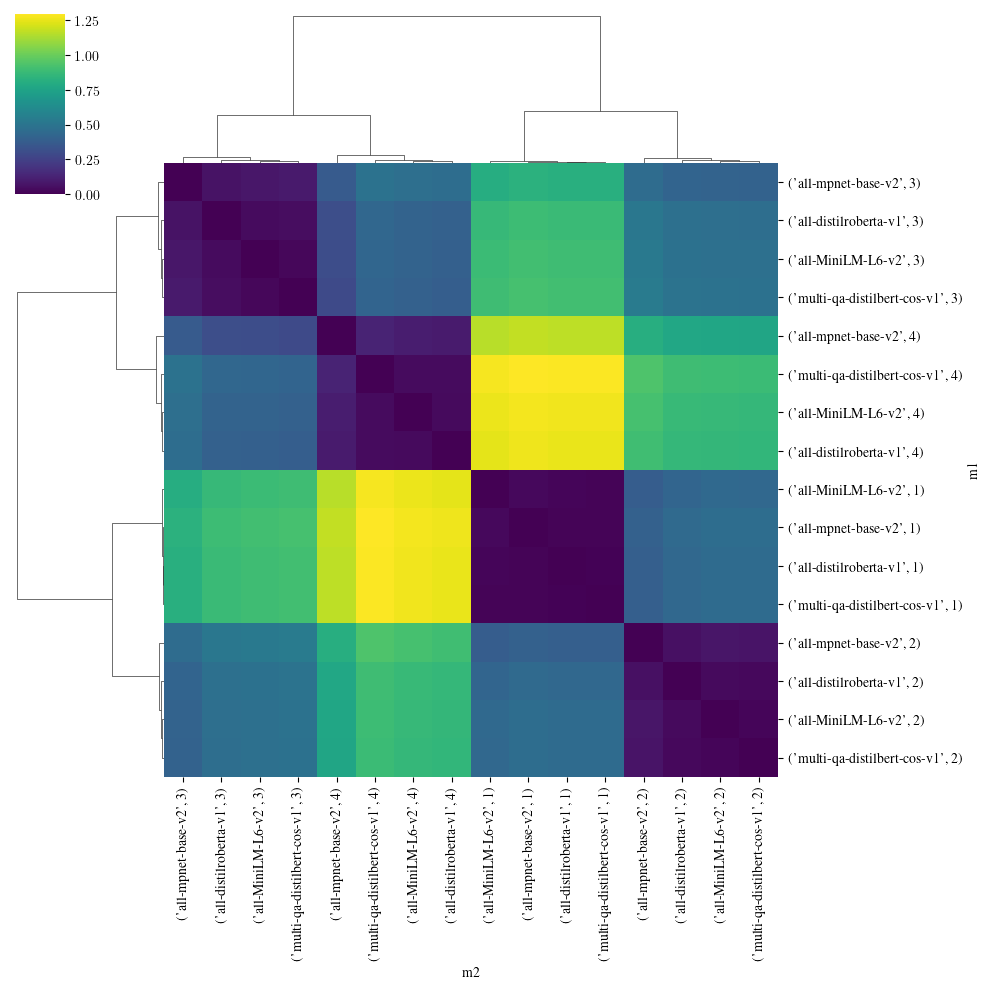

In [139]:
method = "ward"
metric_ = "euclidean"
linkage = hc.linkage(sp.distance.squareform(df), method=method, metric=metric_)
sns.clustermap(df, cmap="viridis", row_linkage=linkage, col_linkage=linkage, )
plt.savefig(f"{paper_figure_path}/language-model-comparison_clustermap-component-variation.pdf", bbox_inches="tight", transparent=True)

In [95]:
dfl = pd.DataFrame(scores).unstack().reset_index(
).rename({0:"score", "level_0":"m1", "level_1":"m2", "level_3":"dim"}, axis=1).groupby(["m1","m2"]
).agg(dict(score=sum)).reset_index()

In [ ]:
sorted_models = ['all-mpnet-base-v2','all-MiniLM-L6-v2', 'all-distilroberta-v1','multi-qa-distilbert-cos-v1']
dfl["m1_nc"] = dfl.m1.map(lambda tup:tup[-1])
dfl["m2_nc"] = dfl.m2.map(lambda tup:tup[-1])
dfl["m1_model"] = dfl.m1.map(lambda tup:tup[0])
dfl["m2_model"] = dfl.m2.map(lambda tup:tup[0])
dfl["models"] = dfl["m1_model"]  + "/" + dfl["m2_model"] 

In [114]:
label_fontsize = 16
legend_fontsize = 12
title_fontsize = 20

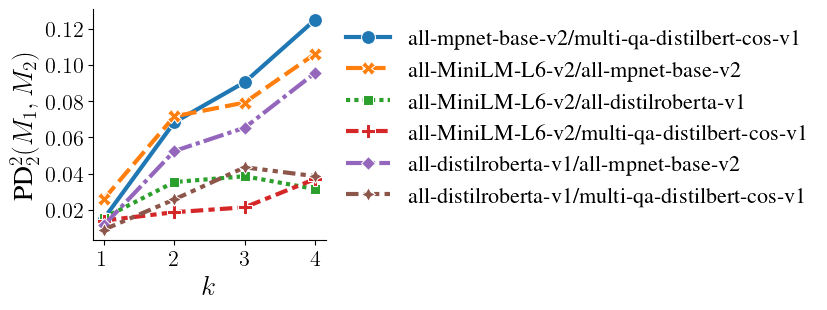

In [138]:
fig, ax = plt.subplots(1,1,figsize=(3,3))
sns.lineplot(data = dfl.query("m1 != m2 and m1_nc == m2_nc"
                             ).sort_values("m1_model", key=lambda vec:vec.map(lambda x:sorted_models.index(x))), y="score", x="m1_nc", 
             hue="models", ax=ax, style="models", lw=3, markers=True, markersize=10)
ax.legend(bbox_to_anchor=(1,1), frameon=False, fontsize=label_fontsize)
ax.set_xlabel("$k$", fontsize=title_fontsize)
ax.set_ylabel(r"PD"+"$^2_2(M_1,M_2)$", fontsize=title_fontsize)
[l.set_fontsize(label_fontsize) for l in ax.get_xticklabels()]
[l.set_fontsize(label_fontsize) for l in ax.get_yticklabels()]
sns.despine(fig)
plt.tight_layout()
plt.savefig(f"{paper_figure_path}/language-model-comparison_component-variation.pdf", bbox_inches="tight", transparent=True)